# Group 13: Systematic Investment Strategy - Very Aggressive Profile

This notebook implements our investment strategy with strictly enforced constraints:
1. **Signal**: Risk-Adjusted Momentum (12m-1m / 60d Volatility).
2. **Optimization**: Maximize Utility $U = E[R] - 0.5 \\lambda (\\sigma^2)^q$ with $\\lambda=1.76, q=0.93$.
3. **Constraints**: Max 30% per GICS Sector, 200% Gross Exposure (100% L / 100% S).

## Step 1: Strategy Parameters & Calibration
We initialize the risk parameters calibrated for our Very Aggressive group profile.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from datetime import datetime, timedelta

# --- GROUP 13 CALIBRATION ---
LAMBDA = 1.76
Q_EXP = 0.93
INITIAL_CASH = 1000000
SECTOR_LIMIT = 0.30

/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Step 2: Data Acquisition & Universe Definition
We fetch S&P 500 components, their sectors, and the benchmark (SPY).

In [2]:
url = 'https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv'
sp500_info = pd.read_csv(url)
sp500_info['Symbol'] = sp500_info['Symbol'].str.replace('.', '-', regex=False)
s_col = 'GICS Sector' if 'GICS Sector' in sp500_info.columns else 'Sector'
sector_map = dict(zip(sp500_info['Symbol'], sp500_info[s_col]))

start_date = (datetime.now() - timedelta(days=365*11)).strftime('%Y-%m-%d')
raw_data = yf.download(list(sector_map.keys()) + ['SPY'], start=start_date)['Close'].ffill()
stock_prices = raw_data.drop(columns=['SPY']).dropna(axis=1, thresh=int(len(raw_data)*0.8))
benchmark = raw_data['SPY'].ffill()

[*********************100%***********************]  504 of 504 completed

2 Failed downloads:
['ADSK', 'CVNA']: TypeError("'NoneType' object is not subscriptable")


## Step 3: Signal Generation
Risk-Adjusted Momentum = (12m - 1m Return) / 60d Volatility.

In [3]:
def get_signals_logic(df):
    # 12-1 Momentum / 60d Volatility
    mom = (df.iloc[-21] / df.iloc[-252]) - 1
    vol = df.tail(61).pct_change().std() * np.sqrt(252)
    score = (mom / vol).replace([np.inf, -np.inf], np.nan).dropna()
    return score.sort_values()

# Current selection for implementation
current_sig = get_signals_logic(stock_prices)
longs = list(current_sig.tail(10).index)
shorts = list(current_sig.head(10).index)

## Step 4: Portfolio Optimization & Results Print
We solve for optimal weights ensuring the 30% sector cap.

In [4]:
def optimize_leg(tkrs, mapping, h_data):
    rets = h_data[tkrs].pct_change().dropna()
    mu, cov = rets.mean() * 252, rets.cov() * 252

    def obj(w):
        p_var = np.dot(w.T, np.dot(cov, w))
        return -(np.sum(mu * w) - 0.5 * LAMBDA * (max(p_var, 1e-6) ** Q_EXP))

    cons = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0}]
    l_secs = [mapping.get(t, 'Other') for t in tkrs]
    for s in set(l_secs):
        idx = [i for i, sec in enumerate(l_secs) if sec == s]
        cons.append({'type': 'ineq', 'fun': lambda w, idx=idx: SECTOR_LIMIT - np.sum(w[idx])})

    res = minimize(obj, [0.1] * 10, method='SLSQP', bounds=[(0.01, 0.25)] * 10, constraints=cons)
    return res.x if res.success else np.array([0.1] * 10)

opt_w_long  = optimize_leg(longs,  sector_map, stock_prices.tail(126))
opt_w_short = optimize_leg(shorts, sector_map, stock_prices.tail(126))

# Compute portfolio-level stats for display
_daily = stock_prices[longs + shorts].tail(126).pct_change().dropna()
_mu    = _daily.mean() * 252
_cov   = _daily.cov()  * 252
_w_all = np.concatenate([opt_w_long / 2, opt_w_short / 2])  # scaled to 200% gross
t_ret  = float(_mu @ _w_all)
t_vol  = float(np.sqrt(_w_all @ _cov @ _w_all))

print("\n--- OPTIMIZATION RESULTS ---")
for t, w in zip(longs,  opt_w_long):  print(f"LONG  {t:5} | {w:.2%} | {sector_map.get(t,'?')}")
for t, w in zip(shorts, opt_w_short): print(f"SHORT {t:5} | {w:.2%} | {sector_map.get(t,'?')}")
print(f"\nExpected Annualized Return   : {t_ret:.2%}")
print(f"Predicted Annualized Volatility: {t_vol:.2%}")


--- OPTIMIZATION RESULTS ---
LONG  TER   | 10.00% | Information Technology
LONG  FIX   | 10.00% | Industrials
LONG  MU    | 10.00% | Information Technology
LONG  EA    | 10.00% | Communication Services
LONG  STX   | 10.00% | Information Technology
LONG  CIEN  | 10.00% | Information Technology
LONG  SATS  | 10.00% | Communication Services
LONG  WDC   | 10.00% | Information Technology
LONG  LITE  | 10.00% | Information Technology
LONG  WBD   | 10.00% | Communication Services
SHORT FISV  | 10.00% | Financials
SHORT CPRT  | 10.00% | Industrials
SHORT ROP   | 10.00% | Information Technology
SHORT IT    | 10.00% | Information Technology
SHORT BRO   | 10.00% | Financials
SHORT PAYX  | 10.00% | Industrials
SHORT AJG   | 10.00% | Financials
SHORT PGR   | 10.00% | Financials
SHORT VRSK  | 10.00% | Industrials
SHORT FIS   | 10.00% | Financials

Expected Annualized Return   : 69.94%
Predicted Annualized Volatility: 21.14%


/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:495: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:501: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])


## Step 5: Backtest with Benchmark Comparison
Comparing Strategy Return vs. S&P 500 (SPY).

/var/folders/q7/2bt1kt6d0xzb95k0cn4jftsr0000gn/T/ipykernel_61393/1169542602.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  vol = df.tail(61).pct_change().std() * np.sqrt(252)
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:495: RuntimeWarning: Values in x were outside bounds during a minimize step, c

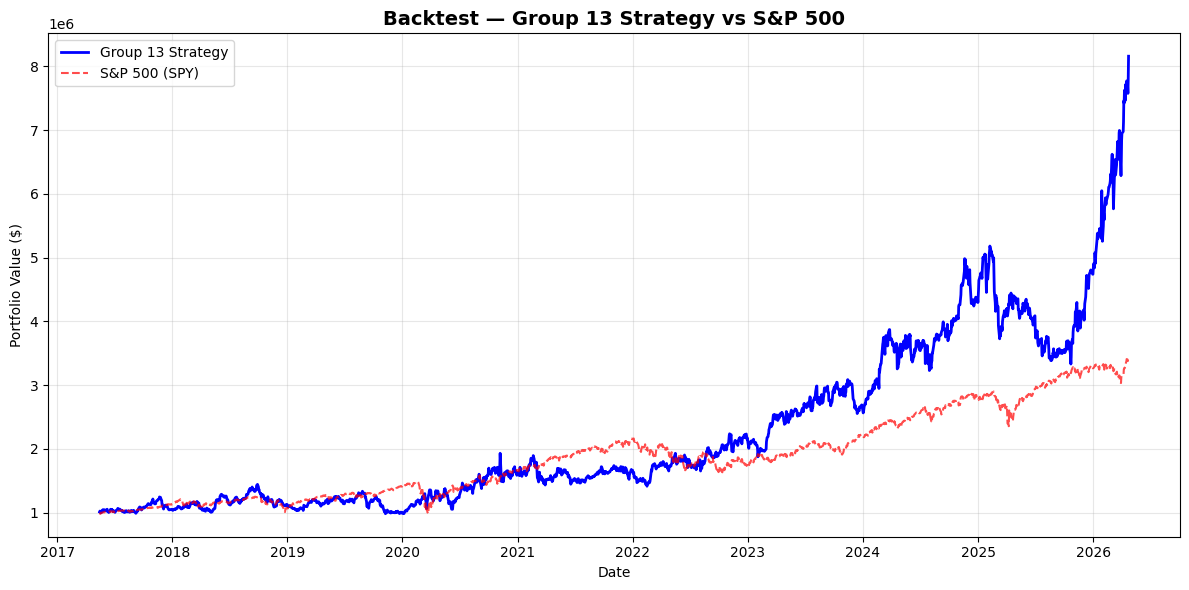

Annualized Return : 26.54%
Final Wealth      : $8,157,709.53


In [5]:
rebalance_dates = benchmark.index[benchmark.index > (benchmark.index[0] + timedelta(days=365))][::21]
portfolio_values, dates_log = [], []
current_wealth = INITIAL_CASH

for i in range(len(rebalance_dates) - 1):
    d_s, d_e = rebalance_dates[i], rebalance_dates[i + 1]
    sig = get_signals_logic(stock_prices.loc[:d_s])
    if sig.empty:
        continue
    l_tkr = list(sig.tail(10).index)
    s_tkr = list(sig.head(10).index)
    lw = optimize_leg(l_tkr, sector_map, stock_prices.loc[:d_s].tail(126))
    sw = optimize_leg(s_tkr, sector_map, stock_prices.loc[:d_s].tail(126))

    period_rets = stock_prices.loc[d_s:d_e].pct_change().dropna()
    if period_rets.empty:
        continue

    daily_rets = (period_rets[l_tkr] @ lw) - (period_rets[s_tkr] @ sw)
    for date, r in daily_rets.items():
        current_wealth *= (1 + r)
        portfolio_values.append(current_wealth)
        dates_log.append(date)

strategy_df   = pd.DataFrame({'Strategy': portfolio_values}, index=dates_log)
benchmark_norm = (benchmark.loc[strategy_df.index] / benchmark.loc[strategy_df.index][0]) * INITIAL_CASH

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(strategy_df['Strategy'], label='Group 13 Strategy', color='blue', lw=2)
ax.plot(benchmark_norm, label='S&P 500 (SPY)', color='red', ls='--', alpha=0.7)
ax.set_title('Backtest — Group 13 Strategy vs S&P 500', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('implementation_backtest.png', dpi=300, bbox_inches='tight')
plt.show()

rets    = strategy_df['Strategy'].pct_change().dropna()
ann_ret = (1 + (strategy_df['Strategy'].iloc[-1] / INITIAL_CASH - 1)) ** (252 / len(rets)) - 1
print(f"Annualized Return : {ann_ret:.2%}")
print(f"Final Wealth      : ${strategy_df['Strategy'].iloc[-1]:,.2f}")

## Step 6: StockTrak Implementation Details

In [6]:
prices = stock_prices.iloc[-1]   # dernière ligne = prix les plus récents

stocktrak = pd.DataFrame({
    'Ticker': longs + shorts,
    'Side':   ['BUY_LONG'] * 10 + ['SELL_SHORT'] * 10,
    'Sector': [sector_map.get(t, '?') for t in (longs + shorts)],
    'Weight': np.concatenate([opt_w_long, opt_w_short]),
    'Price':  [prices[t] for t in (longs + shorts)],
})
stocktrak['Shares'] = (stocktrak['Weight'] * INITIAL_CASH / stocktrak['Price']).astype(int)

print("--- ORDERS FOR STOCKTRAK ---")
print(stocktrak[['Ticker', 'Side', 'Sector', 'Shares', 'Price']].to_string(index=False))

--- ORDERS FOR STOCKTRAK ---
Ticker       Side                 Sector  Shares       Price
   TER   BUY_LONG Information Technology     277  359.769989
   FIX   BUY_LONG            Industrials      51 1952.369995
    MU   BUY_LONG Information Technology     133  746.809998
    EA   BUY_LONG Communication Services     498  200.440002
   STX   BUY_LONG Information Technology     127  782.640015
  CIEN   BUY_LONG Information Technology     182  548.109985
  SATS   BUY_LONG Communication Services     786  127.150002
   WDC   BUY_LONG Information Technology     208  480.000000
  LITE   BUY_LONG Information Technology     110  903.799988
   WBD   BUY_LONG Communication Services    3688   27.110001
  FISV SELL_SHORT             Financials    1802   55.480000
  CPRT SELL_SHORT            Industrials    2946   33.939999
   ROP SELL_SHORT Information Technology     291  343.320007
    IT SELL_SHORT Information Technology     630  158.649994
   BRO SELL_SHORT             Financials    1771   56.45


--- SECTOR AUDIT ---
Side                    LONG  SHORT
Sector                             
Communication Services   0.3    0.0
Financials               0.0    0.5
Industrials              0.1    0.3
Information Technology   0.6    0.2


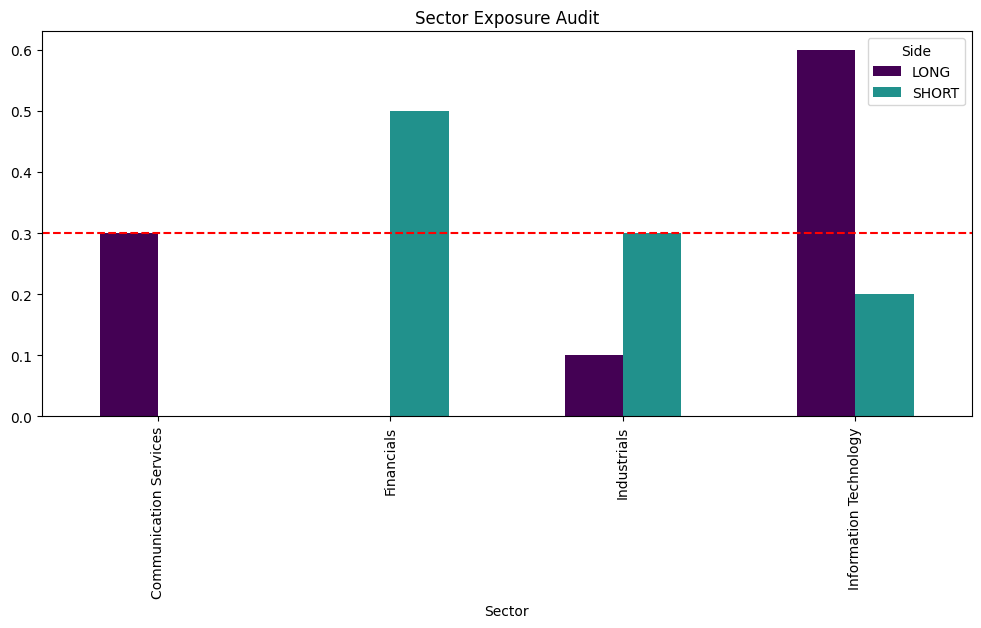

In [7]:
final_table = pd.DataFrame({'Ticker': longs+shorts, 'Side': ['LONG']*10+['SHORT']*10, 
                            'Weight': np.concatenate([opt_w_long, opt_w_short]),
                            'Sector': [sector_map.get(t) for t in longs+shorts]})

audit_df = final_table.groupby(['Side', 'Sector'])['Weight'].sum().unstack(level=0).fillna(0)
print("\n--- SECTOR AUDIT ---")
print(audit_df)

audit_df.plot(kind='bar', figsize=(12,5), color=['#440154', '#21918c'])
plt.axhline(0.30, color='red', ls='--')
plt.title("Sector Exposure Audit"); plt.show()

## Step 7: Efficient Frontier & Utility (Indifference) Curves
We plot the frontier alongside the indifference curves for our Very Aggressive profile.

Computing mathematical efficient frontier …


/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:495: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:501: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])
/Users/jessicabourdouxhe/Library/Python/3.9/lib/python/site-packages/scipy/optim

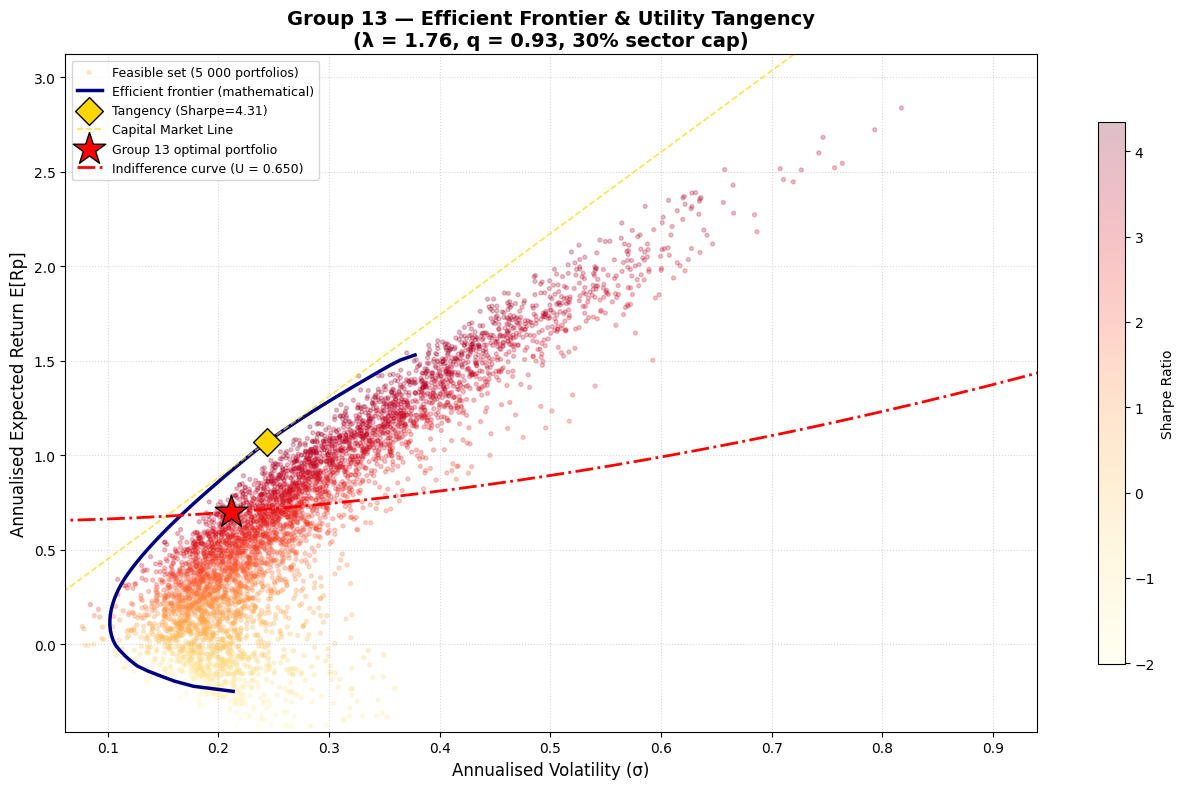


  Group 13 Portfolio  →  E[R] = 69.94%  |  σ = 21.14%  |  U = 0.6505
  Tangency Portfolio  →  E[R] = 107.21%  |  σ = 24.43%  |  Sharpe = 4.31


In [8]:
# --- Step 7: Efficient Frontier (Mathematical) & Indifference Curves ---
# The true frontier is computed by minimizing portfolio variance for each
# target return level — not via random simulation.
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

print("Computing mathematical efficient frontier …")

# ── Data: 20 selected tickers (long + short universe) ────────────────────────
live_tickers = longs + shorts
daily_rets   = stock_prices[live_tickers].tail(126).pct_change().dropna()
mu_vec       = daily_rets.mean() * 252          # annualised expected returns
cov_mat      = daily_rets.cov() * 252           # annualised covariance matrix
n            = len(live_tickers)

# ── 1. Monte Carlo opportunity set (5 000 feasible portfolios) ────────────────
np.random.seed(42)
mc_ret, mc_vol, mc_sharpe = [], [], []
for _ in range(5000):
    w  = np.random.dirichlet(np.ones(n) * 0.2)
    r  = float(mu_vec @ w)
    v  = float(np.sqrt(w @ cov_mat @ w))
    mc_ret.append(r)
    mc_vol.append(v)
    mc_sharpe.append(r / v if v > 0 else 0)

mc_ret    = np.array(mc_ret)
mc_vol    = np.array(mc_vol)
mc_sharpe = np.array(mc_sharpe)

# ── 2. True mathematical efficient frontier ───────────────────────────────────
# For each target return μ*, solve:
#   min  w' Σ w
#   s.t. w' μ = μ*,  Σwᵢ = 1,  wᵢ ∈ [0.01, 0.25]  (same bounds as optimizer)

ret_targets = np.linspace(mu_vec.min() * 0.5, mu_vec.max() * 0.9, 120)
ef_vols, ef_rets = [], []

for mu_target in ret_targets:
    cons = [
        {'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
        {'type': 'eq', 'fun': lambda w, mu_target=mu_target: float(mu_vec @ w) - mu_target},
    ]
    # Sector constraint (same 30% cap as the strategy)
    secs = [sector_map.get(t, 'Other') for t in live_tickers]
    for sec in set(secs):
        idx = [i for i, s in enumerate(secs) if s == sec]
        cons.append({'type': 'ineq',
                     'fun': lambda w, idx=idx: SECTOR_LIMIT - np.sum(w[idx])})

    res = minimize(
        lambda w: float(w @ cov_mat @ w),
        x0=np.ones(n) / n,
        method='SLSQP',
        bounds=[(0.01, 0.25)] * n,
        constraints=cons,
        options={'ftol': 1e-9, 'maxiter': 500},
    )
    if res.success:
        ef_vols.append(np.sqrt(res.fun))
        ef_rets.append(mu_target)

ef_vols = np.array(ef_vols)
ef_rets = np.array(ef_rets)

# ── 3. Tangency portfolio (maximum Sharpe on the frontier) ───────────────────
RF = 0.02
if len(ef_vols) > 0:
    sharpe_ef = (ef_rets - RF) / ef_vols
    tan_idx   = np.argmax(sharpe_ef)
    tan_vol   = ef_vols[tan_idx]
    tan_ret   = ef_rets[tan_idx]
else:
    tan_vol = tan_ret = None

# ── 4. Group 13 optimal portfolio (utility-maximising) ───────────────────────
target_weights = np.concatenate([opt_w_long / 2, opt_w_short / 2])
t_ret = float(mu_vec @ target_weights)
t_vol = float(np.sqrt(target_weights @ cov_mat @ target_weights))
# U = E[R] - 0.5 * λ * (σ²)^q
t_util = t_ret - 0.5 * LAMBDA * (t_vol ** 2) ** Q_EXP

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))

# Feasible set cloud
sc = ax.scatter(mc_vol, mc_ret, c=mc_sharpe, cmap='YlOrRd',
                s=8, alpha=0.25, label='Feasible set (5 000 portfolios)')
plt.colorbar(sc, ax=ax, label='Sharpe Ratio', shrink=0.8)

# True efficient frontier
if len(ef_vols) > 0:
    ax.plot(ef_vols, ef_rets, color='navy', lw=2.5,
            label='Efficient frontier (mathematical)')

# Tangency portfolio
if tan_vol is not None:
    ax.scatter(tan_vol, tan_ret, color='gold', marker='D', s=200,
               edgecolor='black', zorder=11, label=f'Tangency (Sharpe={sharpe_ef[tan_idx]:.2f})')
    # Capital Market Line
    cml_x = np.array([0, mc_vol.max() * 1.1])
    cml_y = RF + (tan_ret - RF) / tan_vol * cml_x
    ax.plot(cml_x, cml_y, color='gold', lw=1.2, ls='--', alpha=0.7, label='Capital Market Line')

# Group 13 optimal portfolio
ax.scatter(t_vol, t_ret, color='red', marker='*', s=600,
           edgecolor='black', zorder=12, label='Group 13 optimal portfolio')

# Indifference curve passing through the optimal portfolio
v_grid = np.linspace(mc_vol.min() * 0.6, mc_vol.max() * 1.2, 200)
indiff = t_util + 0.5 * LAMBDA * ((v_grid ** 2) ** Q_EXP)
mask   = (indiff > mc_ret.min() * 0.8) & (indiff < mc_ret.max() * 1.2)
ax.plot(v_grid[mask], indiff[mask], color='red', lw=2, ls='-.',
        label=f'Indifference curve (U = {t_util:.3f})')

ax.set_title('Group 13 — Efficient Frontier & Utility Tangency\n'
             f'(λ = {LAMBDA}, q = {Q_EXP}, 30% sector cap)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Annualised Volatility (σ)', fontsize=12)
ax.set_ylabel('Annualised Expected Return E[Rp]', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(mc_vol.min() * 0.8, mc_vol.max() * 1.15)
ax.set_ylim(mc_ret.min() * 0.8, mc_ret.max() * 1.1)

plt.tight_layout()
plt.savefig('group13_efficient_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n  Group 13 Portfolio  →  E[R] = {t_ret:.2%}  |  σ = {t_vol:.2%}  |  U = {t_util:.4f}")
if tan_vol is not None:
    print(f"  Tangency Portfolio  →  E[R] = {tan_ret:.2%}  |  σ = {tan_vol:.2%}"
          f"  |  Sharpe = {(tan_ret - RF)/tan_vol:.2f}")
